### 1. Setup: Clone GitHub Repository


In [28]:
import os

# Define the repository URL
repo_url = 'https://github.com/ToufiqImrose/AI-ML.git'
repo_name = repo_url.split('/')[-1].replace('.git', '')


### 2. Data Loading

Now i'll load the `Iris.csv` dataset from the cloned repository into a pandas DataFrame. This will be our standard training data.

In [29]:
import pandas as pd

# Define the path to the Iris dataset within the cloned repository
dataset_path = os.path.join(repo_name, 'AI_ML', 'K-Means Clustering', 'dataset', 'Iris.csv')

# Load the dataset
iris_df = pd.read_csv(dataset_path)

display(iris_df.head())

print("\nInformation about the Iris dataset:")
iris_df.info()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Information about the Iris dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


### 3. Data Preprocessing


In [30]:
from sklearn.preprocessing import StandardScaler

# Drop 'Id' and 'Species' columns as they are not features for clustering
X = iris_df.drop(['Id', 'Species'], axis=1)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a DataFrame for better readability and to maintain column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("First 5 rows of the scaled Iris dataset:")
display(X_scaled_df.head())

print("\nSummary statistics of the scaled Iris dataset:")
display(X_scaled_df.describe())

First 5 rows of the scaled Iris dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977



Summary statistics of the scaled Iris dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-6.631732e-16,3.315866e-16,-2.842171e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.438987e+00,-1.568735e+00,-1.444450e+00
25%,-9.006812e-01,-5.877635e-01,-1.227541e+00,-1.181504e+00
50%,-5.250608e-02,-1.249576e-01,3.362659e-01,1.332259e-01
75%,6.745011e-01,5.692513e-01,7.627586e-01,7.905908e-01
max,2.492019e+00,3.114684e+00,1.786341e+00,1.710902e+00


### 4. Optimal K Selection: The Elbow Method



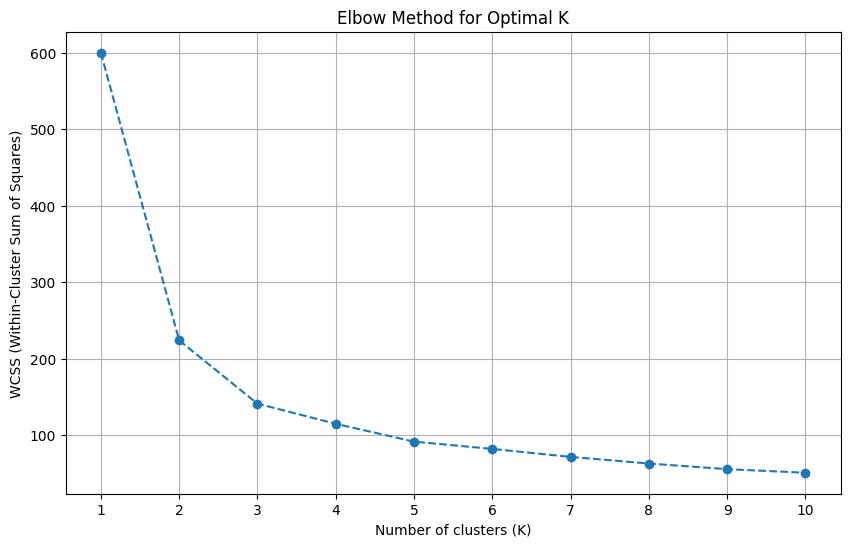


Based on the elbow plot, you can visually inspect to choose the optimal K. Often, K=3 is a good choice for the Iris dataset.


In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# List to store WCSS values for different K
wcss = []

range_n_clusters = range(1, 11)

for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

print("\nBased on the elbow plot, you can visually inspect to choose the optimal K. Often, K=3 is a good choice for the Iris dataset.")

### 5. Model Fitting and Saving


In [32]:
import joblib

# Choose optimal K based on the Elbow Method plot
optimal_k = 3

# Initialize KMeans with the optimal K
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)

# Fit the model to the scaled data
kmeans_model.fit(X_scaled)

# Assign clusters to each data point
clusters = kmeans_model.labels_

# Add the cluster assignments to our scaled DataFrame
X_scaled_df['Cluster'] = clusters

# Display the first few rows with cluster assignments
print("First 5 rows of scaled data with assigned clusters:")
display(X_scaled_df.head())

# Create a directory for models if it doesn't exist
model_dir = os.path.join(repo_name, 'model')
os.makedirs(model_dir, exist_ok=True)

# Define the path to save the model
model_filename = os.path.join(model_dir, 'kmeans_model.joblib')

# Save the trained model
joblib.dump(kmeans_model, model_filename)
print(f"\nK-Means model trained with K={optimal_k} and saved to {model_filename}")

First 5 rows of scaled data with assigned clusters:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Cluster
0,-0.900681,1.032057,-1.341272,-1.312977,1
1,-1.143017,-0.124958,-1.341272,-1.312977,1
2,-1.385353,0.337848,-1.398138,-1.312977,1
3,-1.506521,0.106445,-1.284407,-1.312977,1
4,-1.021849,1.263460,-1.341272,-1.312977,1



K-Means model trained with K=3 and saved to AI-ML/model/kmeans_model.joblib


### 6. Cluster Scatter Plot


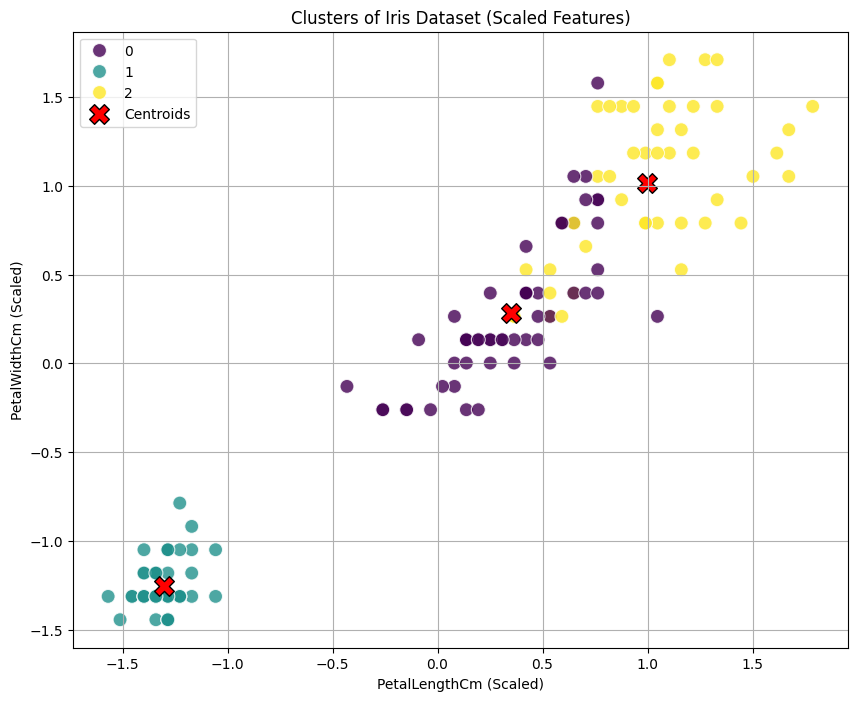

In [33]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_scaled_df['PetalLengthCm'],
    y=X_scaled_df['PetalWidthCm'],
    hue=X_scaled_df['Cluster'],
    palette='viridis',
    s=100,
    alpha=0.8,
    legend='full'
)

centroids = kmeans_model.cluster_centers_
plt.scatter(
    centroids[:, X.columns.get_loc('PetalLengthCm')],
    centroids[:, X.columns.get_loc('PetalWidthCm')],
    marker='X',
    s=200,
    color='red',
    edgecolor='black',
    label='Centroids'
)

plt.title('Clusters of Iris Dataset (Scaled Features)')
plt.xlabel('PetalLengthCm (Scaled)')
plt.ylabel('PetalWidthCm (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

### 7. Custom Data Creation and Loading

As per the assignment, we need to create 10 custom data points that resemble the Iris dataset's features. These points will be formatted into a CSV file and saved in the `dataset/` directory of our repository. Then, we will load this custom data.

In [34]:
import pandas as pd

# Create custom data
custom_data = {
    'SepalLengthCm': [5.0, 4.8, 6.2, 5.5, 7.1, 6.0, 5.2, 5.8, 6.5, 4.7],
    'SepalWidthCm': [3.3, 3.1, 2.8, 4.0, 3.0, 2.7, 3.6, 2.7, 3.2, 3.0],
    'PetalLengthCm': [1.5, 1.3, 4.5, 1.2, 5.9, 5.1, 1.4, 4.1, 5.5, 1.3],
    'PetalWidthCm': [0.2, 0.3, 1.5, 0.4, 2.1, 1.6, 0.2, 1.0, 1.8, 0.2]
}

custom_df = pd.DataFrame(custom_data)

# Define the path to save the custom dataset
custom_dataset_dir = os.path.join(repo_name, 'AI_ML', 'K-Means Clustering', 'dataset')
os.makedirs(custom_dataset_dir, exist_ok=True)
custom_dataset_path = os.path.join(custom_dataset_dir, 'custom_iris_data.csv')

# Save the custom data to a CSV file
custom_df.to_csv(custom_dataset_path, index=False)

print(f"Custom data saved to: {custom_dataset_path}")

# Load the custom data to ensure it's accessible
custom_df_loaded = pd.read_csv(custom_dataset_path)

print("\nLoaded Custom Data:")
display(custom_df_loaded.head(10))

Custom data saved to: AI-ML/AI_ML/K-Means Clustering/dataset/custom_iris_data.csv

Loaded Custom Data:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.0,3.3,1.5,0.2
1,4.8,3.1,1.3,0.3
2,6.2,2.8,4.5,1.5
3,5.5,4.0,1.2,0.4
4,7.1,3.0,5.9,2.1
5,6.0,2.7,5.1,1.6
6,5.2,3.6,1.4,0.2
7,5.8,2.7,4.1,1.0
8,6.5,3.2,5.5,1.8
9,4.7,3.0,1.3,0.2


### 8. Real-World Prediction



In [35]:
# Apply the *same* fitted scaler to the custom data
custom_scaled = scaler.transform(custom_df_loaded)

# Predict clusters for the custom data using the trained K-Means model
custom_clusters = kmeans_model.predict(custom_scaled)

# Add the predicted clusters to the custom DataFrame
custom_df_loaded['Predicted_Cluster'] = custom_clusters

print("Custom Data with Predicted Clusters:")
display(custom_df_loaded)

Custom Data with Predicted Clusters:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Predicted_Cluster
0,5.0,3.3,1.5,0.2,1
1,4.8,3.1,1.3,0.3,1
2,6.2,2.8,4.5,1.5,0
3,5.5,4.0,1.2,0.4,1
4,7.1,3.0,5.9,2.1,2
5,6.0,2.7,5.1,1.6,0
6,5.2,3.6,1.4,0.2,1
7,5.8,2.7,4.1,1.0,0
8,6.5,3.2,5.5,1.8,2
9,4.7,3.0,1.3,0.2,1


### 9. Cluster Interpretation


In [36]:
print("Original Iris Species Distribution:")
display(iris_df['Species'].value_counts())

centroids_original_scale = scaler.inverse_transform(kmeans_model.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original_scale, columns=X.columns)
centroids_df.index.name = 'Cluster'

print("\nCluster Centroids (Original Scale):")
display(centroids_df)

# Interpretation based on typical Iris species characteristics
print("\nCluster Interpretation:")
print("Cluster 1: Likely represents Iris-setosa, characterized by smaller sepal and petal measurements.")
print("Cluster 0: Likely represents Iris-versicolor, with medium sepal and petal lengths/widths.")
print("Cluster 2: Likely represents Iris-virginica, with larger sepal and petal measurements.")


Original Iris Species Distribution:


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50



Cluster Centroids (Original Scale):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Cluster,,,,
0,5.801887,2.673585,4.369811,1.413208
1,5.006000,3.418000,1.464000,0.244000
2,6.780851,3.095745,5.510638,1.972340



Cluster Interpretation:
Cluster 1: Likely represents Iris-setosa, characterized by smaller sepal and petal measurements.
Cluster 0: Likely represents Iris-versicolor, with medium sepal and petal lengths/widths.
Cluster 2: Likely represents Iris-virginica, with larger sepal and petal measurements.
